# TUH EEG 数据预处理

将原始 EDF 文件处理成 HDF5 格式，供 EpiLaBraM 训练使用。

## 数据集用途

| 数据集 | 用途 | 标签 |
|--------|------|------|
| **TUAR** | Stage1 续训 + Stage2 伪迹分类 | 0=bckg, 1=musc, 2=eyem, 3=elec, 4=seiz |
| **TUEG** | Stage1 续训（背景EEG） | 无标签（只生成文件列表） |
| **TUAB** | Stage2 异常检测 | 0=normal, 1=abnormal |
| **TUSZ** | Stage2 发作检测 | 0=background, 1=seizure |
| **TUEV** | Stage2 事件分类 | 0~5（spsw/gped/pled/eyem/artf/bckg） |
| **TUEP** | Stage2 癫痫诊断 | 0=no_epilepsy, 1=epilepsy |

## 预处理流程
1. 读取 EDF，选取标准23通道
2. 重采样至 200 Hz
3. 幅值归一化（V → μV → /100）
4. 对齐到标准23通道（缺失填0）
5. 10s 窗口 / 5s 步进切片 → 存入 `.h5`

## Cell 1：配置路径（修改这里）

In [2]:
# ============================================================
# 修改以下路径后逐格运行
# ============================================================

# 集群上 TUH EEG 原始数据根目录
TUH_ROOT = "/projects/u6da/tuh_eeg"

# 预处理结果输出目录
OUTPUT_DIR = "/projects/u6da/tuh_processed"

# 调试模式：每个 split 最多处理 N 个文件（None = 全部）
MAX_FILES = None   # 测试时设为小数字，正式运行改为 None

# 要处理的数据集（注释掉不需要的）
DATASETS = [
    'tuab',
    'tusz',
    'tuev',
    'tuep',
    'tuar',   # EDF直读，只生成文件列表
    'tueg',   # EDF直读，只生成文件列表
]

# 窗口参数
TARGET_FS      = 200.0   # 目标采样率 Hz
WINDOW_SEC     = 10.0    # 窗口长度（秒）
STRIDE_SEC     = 5.0     # 训练集步长（秒）
EVAL_STRIDE_SEC = 10.0   # 评估集步长（秒，不重叠）

print(f"TUH_ROOT   = {TUH_ROOT}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")
print(f"MAX_FILES  = {MAX_FILES}")
print(f"DATASETS   = {DATASETS}")

TUH_ROOT   = /projects/u6da/tuh_eeg
OUTPUT_DIR = /projects/u6da/tuh_processed
MAX_FILES  = 5
DATASETS   = ['tuab', 'tusz', 'tuev', 'tuep', 'tuar', 'tueg']


## Cell 2：导入依赖

In [3]:
import os
import sys
import glob
import json
import traceback
from pathlib import Path
from typing import List, Tuple, Optional, Dict
from collections import defaultdict

import numpy as np
import h5py
import mne
import matplotlib.pyplot as plt
import matplotlib
from tqdm.auto import tqdm
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']

mne.set_log_level('WARNING')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Imports OK")
print(f"MNE version: {mne.__version__}")
print(f"h5py version: {h5py.__version__}")

Imports OK
MNE version: 1.11.0
h5py version: 3.16.0


## Cell 3：常量与工具函数

In [4]:
STANDARD_23 = [
    'FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2',
    'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'CZ', 'PZ', 'A1', 'A2', 'T1', 'T2',
]
STD_IDX = {ch: i for i, ch in enumerate(STANDARD_23)}

# TUH EDF 通道名 → 标准名映射（覆盖 -REF / -LE / "EEG " 前缀等变体）
_ALIAS_MAP: Dict[str, str] = {}
for _ch in STANDARD_23:
    for _variant in [_ch, f'EEG {_ch}-REF', f'EEG {_ch}-LE', f'{_ch}-REF', f'{_ch}-LE', f'EEG {_ch}']:
        _ALIAS_MAP[_variant.upper()] = _ch

# TUEV 6类
TUEV_LABELS     = {'spsw': 0, 'gped': 1, 'pled': 2, 'eyem': 3, 'artf': 4, 'bckg': 5}
TUEV_CLASS_NAMES = ['spsw', 'gped', 'pled', 'eyem', 'artf', 'bckg']

# TUSZ 发作标签集合
TUSZ_SEIZURE_LABELS = {
    'fnsz','gnsz','absz','tnsz','cpsz','tcsz','mysz',
    'spsz','cnsz','atsz','nesz','seiz',
}

# -------------------------------------------------------
def load_and_preprocess_edf(
    edf_path: str,
    target_fs: float = TARGET_FS,
) -> Tuple[Optional[np.ndarray], List[str], float]:
    """
    读取 EDF → 选通道 → 重采样 → μV → /100 归一化 → 对齐23通道
    返回: (eeg [23,T] float32, ch_names, orig_fs)  或  (None, [], 0)
    """
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    except Exception as e:
        print(f"  [ERROR] {Path(edf_path).name}: {e}")
        return None, [], 0.0

    orig_fs = raw.info['sfreq']
    available = [ch for ch in raw.ch_names
                 if _ALIAS_MAP.get(ch.upper().strip())]
    if not available:
        return None, [], orig_fs

    raw.pick_channels(available, ordered=False)
    if abs(orig_fs - target_fs) > 1.0:
        raw.resample(target_fs, verbose=False)

    data = raw.get_data() * 1e6   # V → μV
    T = data.shape[1]
    aligned = np.zeros((23, T), dtype=np.float32)
    for i, ch in enumerate(raw.ch_names):
        std = _ALIAS_MAP.get(ch.upper().strip())
        if std and std in STD_IDX:
            aligned[STD_IDX[std]] = data[i].astype(np.float32)

    aligned /= 100.0   # 归一化
    return aligned, STANDARD_23, orig_fs

print("工具函数定义完毕")

工具函数定义完毕


## Cell 4：检查数据目录结构

In [5]:
print(f"TUH_ROOT = {TUH_ROOT}")
print()

for ds in ['tuab', 'tusz', 'tuev', 'tuep', 'tuar', 'tueg']:
    ds_path = os.path.join(TUH_ROOT, ds)
    if not os.path.exists(ds_path):
        print(f"  [MISSING] {ds_path}")
        continue
    # 统计 EDF 文件数
    edfs = glob.glob(os.path.join(ds_path, '**', '*.edf'), recursive=True)
    print(f"  {ds.upper():>6}: {len(edfs):>6} EDF files  →  {ds_path}")
    # 展示前2级子目录
    for entry in sorted(os.listdir(ds_path))[:6]:
        sub = os.path.join(ds_path, entry)
        if os.path.isdir(sub):
            n_sub = len(os.listdir(sub))
            print(f"           ├── {entry}/  ({n_sub} items)")

TUH_ROOT = /projects/u6da/tuh_eeg

    TUAB:   2993 EDF files  →  /projects/u6da/tuh_eeg/tuab
           ├── edf/  (3 items)
    TUSZ:   8139 EDF files  →  /projects/u6da/tuh_eeg/tusz
           ├── DOCS/  (6 items)
           ├── edf/  (3 items)
    TUEV:    518 EDF files  →  /projects/u6da/tuh_eeg/tuev
           ├── edf/  (3 items)
    TUEP:   2821 EDF files  →  /projects/u6da/tuh_eeg/tuep
           ├── 00_epilepsy/  (101 items)
           ├── 01_no_epilepsy/  (101 items)
           ├── DOCS/  (8 items)
    TUAR:    310 EDF files  →  /projects/u6da/tuh_eeg/tuar
           ├── DOCS/  (5 items)
           ├── edf/  (4 items)
    TUEG:  69672 EDF files  →  /projects/u6da/tuh_eeg/tueg
           ├── DOCS/  (2 items)
           ├── edf/  (152 items)


## Cell 5：测试读取一个 EDF 文件

In [6]:
# 找一个 EDF 文件来测试
test_ds = 'tuab'   # 可改成其他数据集
test_edfs = glob.glob(os.path.join(TUH_ROOT, test_ds, '**', '*.edf'), recursive=True)

if not test_edfs:
    print(f"[WARN] 在 {test_ds} 下没找到 EDF 文件，尝试其他数据集")
else:
    edf_path = test_edfs[0]
    print(f"测试文件: {edf_path}")

    eeg, ch_names, orig_fs = load_and_preprocess_edf(edf_path)
    if eeg is not None:
        T = eeg.shape[1]
        dur_s = T / TARGET_FS
        print(f"\n原始采样率: {orig_fs} Hz  →  重采样至 {TARGET_FS} Hz")
        print(f"EEG shape:  {eeg.shape}  （23通道 × {T}点 = {dur_s:.1f}秒）")
        print(f"幅值范围:   [{eeg.min():.4f}, {eeg.max():.4f}]（归一化后，单位≈0.01mV）")
        print(f"\n通道覆盖（有效通道数={np.any(eeg != 0, axis=1).sum()}/23）:")
        valid_mask = np.any(eeg != 0, axis=1)
        for i, (ch, valid) in enumerate(zip(STANDARD_23, valid_mask)):
            mark = '✓' if valid else '✗'
            print(f"  {mark} {ch}", end='   ')
            if (i + 1) % 6 == 0:
                print()
        print()

测试文件: /projects/u6da/tuh_eeg/tuab/edf/eval/abnormal/01_tcp_ar/aaaaapqd_s001_t000.edf

原始采样率: 250.0 Hz  →  重采样至 200.0 Hz
EEG shape:  (23, 264800)  （23通道 × 264800点 = 1324.0秒）
幅值范围:   [-42.1921, 53.4830]（归一化后，单位≈0.01mV）

通道覆盖（有效通道数=23/23）:
  ✓ FP1     ✓ FP2     ✓ F3     ✓ F4     ✓ C3     ✓ C4   
  ✓ P3     ✓ P4     ✓ O1     ✓ O2     ✓ F7     ✓ F8   
  ✓ T3     ✓ T4     ✓ T5     ✓ T6     ✓ FZ     ✓ CZ   
  ✓ PZ     ✓ A1     ✓ A2     ✓ T1     ✓ T2   


## Cell 6：可视化一段 EEG

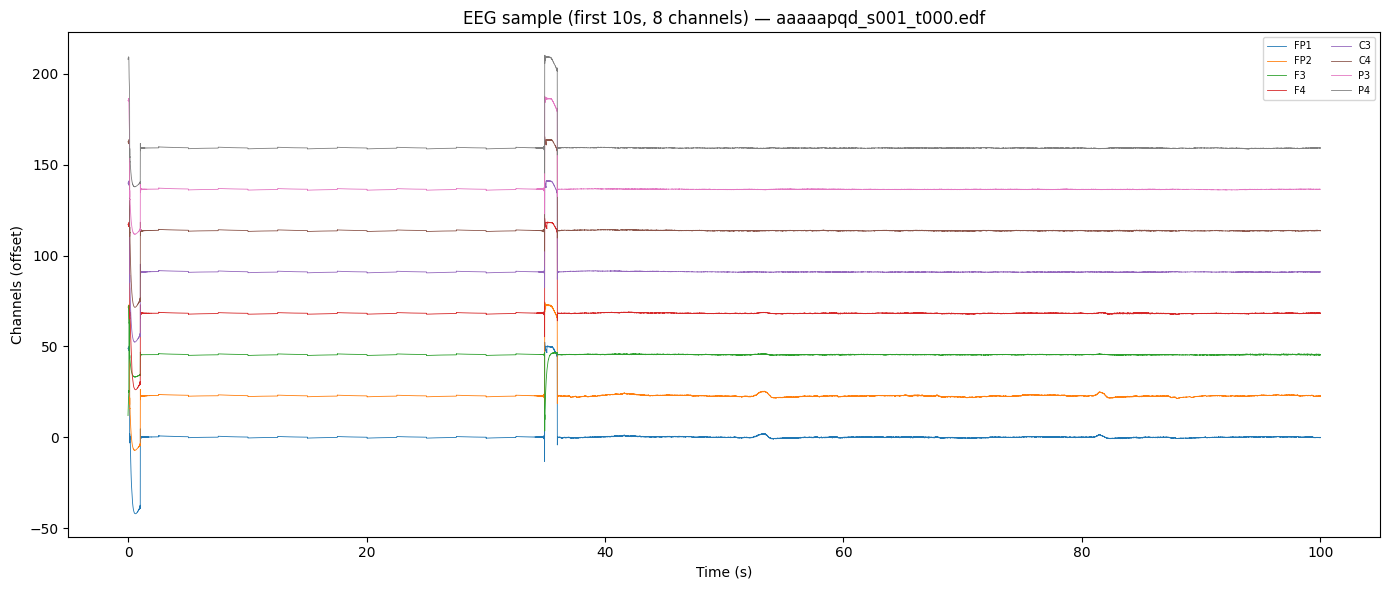

In [9]:
if eeg is not None:
    # 显示前10秒，前8个通道
    n_show_ch  = 8
    n_show_pts = int(100 * TARGET_FS)
    t = np.arange(n_show_pts) / TARGET_FS

    fig, ax = plt.subplots(figsize=(14, 6))
    offset = 0
    step = eeg[:n_show_ch, :n_show_pts].std() * 4
    if step < 1e-6:
        step = 0.5

    for i in range(n_show_ch):
        ch_data = eeg[i, :n_show_pts]
        ax.plot(t, ch_data + offset, lw=0.6, color=f'C{i}', label=STANDARD_23[i])
        offset += step

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Channels (offset)')
    ax.set_title(f'EEG sample (first 10s, 8 channels) — {Path(edf_path).name}')
    ax.legend(loc='upper right', fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

## Cell 7：处理 TUAB（正常/异常二分类）

In [10]:
def process_tuab(tuh_root, output_dir, max_files=None,
                 window_sec=WINDOW_SEC, stride_sec=STRIDE_SEC,
                 eval_stride_sec=EVAL_STRIDE_SEC):
    print("=" * 60)
    print("TUAB — 异常检测  |  0=normal, 1=abnormal")
    print("=" * 60)

    tuab_root = os.path.join(tuh_root, 'tuab')
    found_any = False

    for split in ('train', 'eval'):
        stride = stride_sec if split == 'train' else eval_stride_sec
        win = int(window_sec * TARGET_FS)
        stp = int(stride * TARGET_FS)
        counts = defaultdict(int)
        skipped = 0

        for label_name, label_id in [('normal', 0), ('abnormal', 1)]:
            # 尝试 edf/{split}/{label_name} 和 {split}/{label_name} 两种路径
            for base in (
                os.path.join(tuab_root, 'edf', split, label_name),
                os.path.join(tuab_root, split, label_name),
            ):
                files = sorted(glob.glob(os.path.join(base, '**', '*.edf'), recursive=True))
                if files:
                    break

            if not files:
                continue
            found_any = True
            if max_files:
                files = files[:max_files]

            out_dir = os.path.join(output_dir, 'tuab', split, label_name)
            os.makedirs(out_dir, exist_ok=True)
            print(f"  [{split}/{label_name}]  {len(files)} files")

            for edf_path in tqdm(files, desc=f"TUAB {split}/{label_name}", unit="file"):
                rec_id = Path(edf_path).stem
                out_path = os.path.join(out_dir, f'{rec_id}.h5')
                if os.path.exists(out_path):
                    counts[label_name] += 1
                    continue

                eeg, ch_names, _ = load_and_preprocess_edf(edf_path)
                if eeg is None:
                    skipped += 1
                    continue

                segs = [eeg[:, s:s+win] for s in range(0, eeg.shape[1]-win+1, stp)]
                if not segs:
                    skipped += 1
                    continue

                with h5py.File(out_path, 'w') as hf:
                    grp = hf.create_group(rec_id)
                    ds_arr = grp.create_dataset('eeg', data=np.stack(segs),
                                                compression='gzip', compression_opts=4)
                    ds_arr.attrs['chOrder'] = ch_names
                    ds_arr.attrs['label']   = label_id
                    grp.attrs['n_segments'] = len(segs)

                counts[label_name] += len(segs)

        if found_any:
            print(f"    normal: {counts['normal']:>8}  abnormal: {counts['abnormal']:>8}  skipped: {skipped}")

    if not found_any:
        print(f"  [WARN] 未找到 EDF 文件，请检查路径: {tuab_root}")


if 'tuab' in DATASETS:
    process_tuab(TUH_ROOT, OUTPUT_DIR, MAX_FILES)

TUAB — 异常检测  |  0=normal, 1=abnormal
  [train/normal]  5 files
  [train/abnormal]  5 files
    normal:     1263  abnormal:     1347  skipped: 0
  [eval/normal]  5 files
  [eval/abnormal]  5 files
    normal:      630  abnormal:      662  skipped: 0


## Cell 8：处理 TUSZ（发作检测）

In [13]:
def _parse_tusz_csv(csv_path: str):
    """格式：channel,start_time,stop_time,label,confidence（每个事件多行，按通道重复）"""
    events = []
    seen = set()
    try:
        with open(csv_path) as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#') or line.startswith('channel'):
                    continue
                parts = line.split(',')
                if len(parts) < 4:
                    continue
                try:
                    start, stop = float(parts[1]), float(parts[2])
                    label = parts[3].lower().strip()
                except (ValueError, IndexError):
                    continue
                key = (start, stop, label)
                if key not in seen:
                    seen.add(key)
                    events.append((start, stop, int(label in TUSZ_SEIZURE_LABELS)))
    except Exception:
        return None
    return events or None


def _parse_tusz_tse(tse_path: str):
    """格式：start_time stop_time label（旧版 .tse）"""
    if not os.path.exists(tse_path):
        return None
    events = []
    try:
        with open(tse_path) as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#') or line.startswith('version'):
                    continue
                parts = line.split()
                if len(parts) < 3:
                    continue
                start, stop, label = float(parts[0]), float(parts[1]), parts[2].lower()
                events.append((start, stop, int(label in TUSZ_SEIZURE_LABELS)))
    except Exception:
        return None
    return events or None


def _parse_tusz_annotation(edf_path: str):
    """优先 .csv，其次 .tse"""
    csv_path = edf_path.replace('.edf', '.csv')
    tse_path = edf_path.replace('.edf', '.tse')
    if os.path.exists(csv_path):
        return _parse_tusz_csv(csv_path)
    elif os.path.exists(tse_path):
        return _parse_tusz_tse(tse_path)
    return None


def process_tusz(tuh_root, output_dir, max_files=None,
                 window_sec=WINDOW_SEC, stride_sec=STRIDE_SEC,
                 eval_stride_sec=EVAL_STRIDE_SEC):
    print("=" * 60)
    print("TUSZ — 发作检测  |  0=background, 1=seizure")
    print("=" * 60)

    tusz_root = os.path.join(tuh_root, 'tusz')
    found_any = False

    for split in ('train', 'dev', 'eval'):
        stride = stride_sec if split == 'train' else eval_stride_sec
        win = int(window_sec * TARGET_FS)
        stp = int(stride * TARGET_FS)

        for base in (
            os.path.join(tusz_root, 'edf', split),
            os.path.join(tusz_root, split),
        ):
            files = sorted(glob.glob(os.path.join(base, '**', '*.edf'), recursive=True))
            if files:
                break
        if not files:
            continue
        found_any = True
        if max_files:
            files = files[:max_files]

        out_dir = os.path.join(output_dir, 'tusz', split)
        os.makedirs(out_dir, exist_ok=True)
        print(f"  [{split}]  {len(files)} files")

        n_bckg = n_seiz = skipped = 0
        for edf_path in tqdm(files, desc=f"TUSZ {split}", unit="file"):
            rec_id = Path(edf_path).stem
            out_path = os.path.join(out_dir, f'{rec_id}.h5')
            if os.path.exists(out_path):
                continue

            events = _parse_tusz_annotation(edf_path)
            eeg, ch_names, _ = load_and_preprocess_edf(edf_path)
            if eeg is None:
                skipped += 1
                continue

            T = eeg.shape[1]
            label_arr = np.zeros(T, dtype=np.int8)
            if events:
                for s_t, e_t, lbl in events:
                    s, e = int(s_t * TARGET_FS), min(int(e_t * TARGET_FS), T)
                    if s < e:
                        label_arr[s:e] = lbl

            segs, labels = [], []
            for start in range(0, T - win + 1, stp):
                seg_lbl = label_arr[start:start + win]
                lbl = 1 if seg_lbl.sum() > win * 0.3 else 0
                segs.append(eeg[:, start:start + win])
                labels.append(lbl)
                n_seiz += lbl
                n_bckg += (1 - lbl)

            if not segs:
                skipped += 1
                continue

            with h5py.File(out_path, 'w') as hf:
                grp = hf.create_group(rec_id)
                ds_arr = grp.create_dataset('eeg', data=np.stack(segs),
                                            compression='gzip', compression_opts=4)
                ds_arr.attrs['chOrder'] = ch_names
                grp.create_dataset('label', data=np.array(labels, dtype=np.int8))
                grp.attrs['n_segments'] = len(segs)

        print(f"    background: {n_bckg:>8}  seizure: {n_seiz:>8}  skipped: {skipped}")

    if not found_any:
        print(f"  [WARN] 未找到 EDF 文件，请检查路径: {tusz_root}")


if 'tusz' in DATASETS:
    process_tusz(TUH_ROOT, OUTPUT_DIR, MAX_FILES)

TUSZ — 发作检测  |  0=background, 1=seizure
  [train]  5 files
    background:        0  seizure:        0  skipped: 0
  [dev]  5 files
    background:        0  seizure:        0  skipped: 1
  [eval]  5 files
    background:        0  seizure:        0  skipped: 0


## Cell 9：处理 TUEV（6类事件分类）

In [14]:
def _tuev_label_from_filename(edf_path: str) -> Optional[int]:
    """Eval set: 文件名前缀即类别（如 spsw_067_a_1.edf → spsw=0）"""
    stem = Path(edf_path).stem.lower()
    for cls_name in TUEV_LABELS:
        if stem.startswith(cls_name + '_') or stem == cls_name:
            return TUEV_LABELS[cls_name]
    return None


def _tuev_label_from_lab(edf_path: str) -> Optional[int]:
    """Train set: 从 ch000.lab 文件读取标签
    格式：start_sample  end_sample  label（只记录非背景事件）
    策略：有非 bckg 事件则取持续时间最长的那个，否则返回 bckg
    """
    lab_path = edf_path.replace('.edf', '_ch000.lab')
    if not os.path.exists(lab_path):
        return None
    counts = defaultdict(float)
    try:
        with open(lab_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 3:
                    continue
                label = parts[2].lower()
                try:
                    duration = int(parts[1]) - int(parts[0])
                except ValueError:
                    continue
                if label in TUEV_LABELS:
                    counts[label] += duration
        if not counts:
            return TUEV_LABELS['bckg']
        # 优先取非 bckg 标签（文件中只标注事件，其余隐含为 bckg）
        non_bckg = {k: v for k, v in counts.items() if k != 'bckg'}
        if non_bckg:
            return TUEV_LABELS[max(non_bckg, key=lambda k: non_bckg[k])]
        return TUEV_LABELS['bckg']
    except Exception:
        return None


def process_tuev(tuh_root, output_dir, max_files=None,
                 window_sec=WINDOW_SEC, stride_sec=STRIDE_SEC,
                 eval_stride_sec=EVAL_STRIDE_SEC):
    print("=" * 60)
    print("TUEV — 事件分类  |  0=spsw 1=gped 2=pled 3=eyem 4=artf 5=bckg")
    print("=" * 60)
    print("  标签来源: train→ch000.lab多数标签  eval→文件名前缀")

    tuev_root = os.path.join(tuh_root, 'tuev')
    found_any = False

    for split in ('train', 'eval'):
        stride = stride_sec if split == 'train' else eval_stride_sec
        win = int(window_sec * TARGET_FS)
        stp = int(stride * TARGET_FS)
        cls_counts = defaultdict(int)
        skipped = 0

        base = os.path.join(tuev_root, 'edf', split)
        if not os.path.exists(base):
            print(f"  [WARN] 未找到: {base}")
            continue

        edf_files = sorted(glob.glob(os.path.join(base, '**', '*.edf'), recursive=True))
        if not edf_files:
            print(f"  [WARN] {base} 下无 EDF 文件")
            continue

        found_any = True
        if max_files:
            edf_files = edf_files[:max_files]

        # 提取标签
        entries = []
        for f in edf_files:
            if split == 'eval':
                cls_id = _tuev_label_from_filename(f)
            else:
                cls_id = _tuev_label_from_lab(f)
            if cls_id is None:
                cls_id = TUEV_LABELS['bckg']  # 无法解析时默认 bckg
            entries.append((f, cls_id))

        for cls_name in TUEV_CLASS_NAMES:
            os.makedirs(os.path.join(output_dir, 'tuev', split, cls_name), exist_ok=True)

        print(f"  [{split}]  {len(entries)} files")
        for edf_path, cls_id in tqdm(entries, desc=f"TUEV {split}", unit="file"):
            cls_name = TUEV_CLASS_NAMES[cls_id]
            rec_id   = Path(edf_path).stem
            out_path = os.path.join(output_dir, 'tuev', split, cls_name, f'{rec_id}.h5')
            if os.path.exists(out_path):
                cls_counts[cls_name] += 1
                continue

            eeg, ch_names, _ = load_and_preprocess_edf(edf_path)
            if eeg is None:
                skipped += 1
                continue

            T = eeg.shape[1]
            segs = [eeg[:, s:s+win] for s in range(0, T - win + 1, stp)]
            if not segs:
                skipped += 1
                continue

            with h5py.File(out_path, 'w') as hf:
                grp = hf.create_group(rec_id)
                ds_arr = grp.create_dataset('eeg', data=np.stack(segs),
                                            compression='gzip', compression_opts=4)
                ds_arr.attrs['chOrder'] = ch_names
                ds_arr.attrs['label']   = cls_id
                grp.attrs['n_segments'] = len(segs)
            cls_counts[cls_name] += len(segs)

        for cls in TUEV_CLASS_NAMES:
            print(f"    {cls:>6}: {cls_counts[cls]:>8} segments")
        if skipped:
            print(f"    skipped: {skipped}")

    if not found_any:
        print(f"  [WARN] 未找到 EDF 文件，请检查路径: {tuev_root}")


if 'tuev' in DATASETS:
    process_tuev(TUH_ROOT, OUTPUT_DIR, MAX_FILES)

TUEV — 事件分类  |  0=spsw 1=gped 2=pled 3=eyem 4=artf 5=bckg
  [WARN] 未找到 EDF 文件，请检查路径: /projects/u6da/tuh_eeg/tuev


In [ ]:
# (epilabram) taotl.u6da@login44:/projects/u6da/tuh_eeg/tuep> cd /projects/u6da/tuh_eeg/tuev
# (epilabram) taotl.u6da@login44:/projects/u6da/tuh_eeg/tuev> ls
# AAREADME.txt  AAREADME.txt,v  edf


## Cell 10：处理 TUEP（癫痫诊断）

In [15]:
def process_tuep(tuh_root, output_dir, max_files=None,
                 window_sec=WINDOW_SEC, stride_sec=STRIDE_SEC,
                 eval_stride_sec=EVAL_STRIDE_SEC,
                 train_ratio=0.8, seed=42):
    print("=" * 60)
    print("TUEP — 癫痫诊断  |  0=no_epilepsy, 1=epilepsy")
    print("=" * 60)

    tuep_root = os.path.join(tuh_root, 'tuep')
    win = int(window_sec * TARGET_FS)

    # 实际目录结构：tuep/00_epilepsy/患者ID/session/... 和 tuep/01_no_epilepsy/...
    # 没有官方 train/eval 分割，按患者 ID 做 80/20 分割
    label_map = [
        ('00_epilepsy',   1, 'epilepsy'),
        ('01_no_epilepsy', 0, 'no_epilepsy'),
    ]

    found_any = False
    rng = np.random.default_rng(seed)

    for dir_name, label_id, label_name in label_map:
        base = os.path.join(tuep_root, dir_name)
        if not os.path.exists(base):
            print(f"  [WARN] 目录不存在: {base}")
            continue

        # 按患者 ID 分组，避免同一患者跨 split
        patient_dirs = sorted([
            d for d in os.listdir(base)
            if os.path.isdir(os.path.join(base, d))
        ])
        if not patient_dirs:
            print(f"  [WARN] {base} 下无子目录")
            continue

        rng.shuffle(patient_dirs := np.array(patient_dirs))
        n_train = int(len(patient_dirs) * train_ratio)
        split_map = {p: 'train' for p in patient_dirs[:n_train]}
        split_map.update({p: 'eval' for p in patient_dirs[n_train:]})

        all_files = sorted(glob.glob(os.path.join(base, '**', '*.edf'), recursive=True))
        if not all_files:
            print(f"  [WARN] {base} 下无 EDF 文件")
            continue

        found_any = True
        if max_files:
            all_files = all_files[:max_files]

        counts = defaultdict(int)
        skipped = 0

        for edf_path in tqdm(all_files, desc=f"TUEP {label_name}", unit="file"):
            # 从路径推断患者 ID（dir_name 下的第一级子目录）
            rel = os.path.relpath(edf_path, base)
            patient_id = rel.split(os.sep)[0]
            split = split_map.get(patient_id, 'train')
            stride = stride_sec if split == 'train' else eval_stride_sec
            stp = int(stride * TARGET_FS)

            out_dir = os.path.join(output_dir, 'tuep', split, label_name)
            os.makedirs(out_dir, exist_ok=True)

            rec_id   = Path(edf_path).stem
            out_path = os.path.join(out_dir, f'{rec_id}.h5')
            if os.path.exists(out_path):
                counts[split] += 1
                continue

            eeg, ch_names, _ = load_and_preprocess_edf(edf_path)
            if eeg is None:
                skipped += 1
                continue

            T = eeg.shape[1]
            segs = [eeg[:, s:s+win] for s in range(0, T - win + 1, stp)]
            if not segs:
                skipped += 1
                continue

            with h5py.File(out_path, 'w') as hf:
                grp = hf.create_group(rec_id)
                ds_arr = grp.create_dataset('eeg', data=np.stack(segs),
                                            compression='gzip', compression_opts=4)
                ds_arr.attrs['chOrder'] = ch_names
                ds_arr.attrs['label']   = label_id
                grp.attrs['n_segments'] = len(segs)
            counts[split] += len(segs)

        print(f"  {label_name}: train={counts['train']}  eval={counts['eval']}  skipped={skipped}")

    if not found_any:
        print(f"  [WARN] 未找到 EDF 文件，请检查路径: {tuep_root}")


if 'tuep' in DATASETS:
    process_tuep(TUH_ROOT, OUTPUT_DIR, MAX_FILES)

TUEP — 癫痫诊断  |  0=no_epilepsy, 1=epilepsy
  [WARN] 未找到 EDF 文件，请检查路径: /projects/u6da/tuh_eeg/tuep


In [ ]:
# (epilabram) taotl.u6da@login44:/projects/u6da/tuh_eeg/tuep> ls
# 00_epilepsy  01_no_epilepsy  AAREADME.txt  DOCS



## Cell 11：TUAR / TUEG 生成 EDF 文件列表

In [16]:
def process_edf_filelist(ds_name, tuh_root, output_dir, max_files=None):
    """
    TUAR / TUEG 不转 h5，训练时直接读 EDF。
    这里只把文件路径写入 {split}_files.txt。
    """
    print("=" * 60)
    print(f"{ds_name.upper()} — EDF 文件列表（直接读取）")
    print("=" * 60)

    ds_root = os.path.join(tuh_root, ds_name)
    out_dir = os.path.join(output_dir, ds_name)
    os.makedirs(out_dir, exist_ok=True)

    found_any = False
    for split in ('train', 'eval', 'dev'):
        for base in (
            os.path.join(ds_root, 'edf', split),
            os.path.join(ds_root, split),
            ds_root,
        ):
            files = sorted(glob.glob(os.path.join(base, '**', '*.edf'), recursive=True))
            if files:
                break
        if not files:
            continue
        found_any = True
        if max_files:
            files = files[:max_files]

        list_path = os.path.join(out_dir, f'{split}_files.txt')
        with open(list_path, 'w') as f:
            for fp in files:
                f.write(fp + '\n')
        print(f"  [{split}]  {len(files)} files  →  {list_path}")

    if not found_any:
        print(f"  [WARN] 未找到 EDF 文件，请检查路径: {ds_root}")


if 'tuar' in DATASETS:
    process_edf_filelist('tuar', TUH_ROOT, OUTPUT_DIR, MAX_FILES)

if 'tueg' in DATASETS:
    process_edf_filelist('tueg', TUH_ROOT, OUTPUT_DIR, MAX_FILES)

TUAR — EDF 文件列表（直接读取）
  [train]  5 files  →  /projects/u6da/tuh_processed/tuar/train_files.txt
  [eval]  5 files  →  /projects/u6da/tuh_processed/tuar/eval_files.txt
  [dev]  5 files  →  /projects/u6da/tuh_processed/tuar/dev_files.txt
TUEG — EDF 文件列表（直接读取）
  [train]  5 files  →  /projects/u6da/tuh_processed/tueg/train_files.txt
  [eval]  5 files  →  /projects/u6da/tuh_processed/tueg/eval_files.txt
  [dev]  5 files  →  /projects/u6da/tuh_processed/tueg/dev_files.txt


## Cell 12：统计汇总与可视化

处理结果汇总
    TUAB:    20 h5 files        3902 segments
    TUSZ:    14 h5 files        1315 segments
    TUAR:    15 EDF files listed
    TUEG:    15 EDF files listed

Summary saved → /projects/u6da/tuh_processed/summary.json


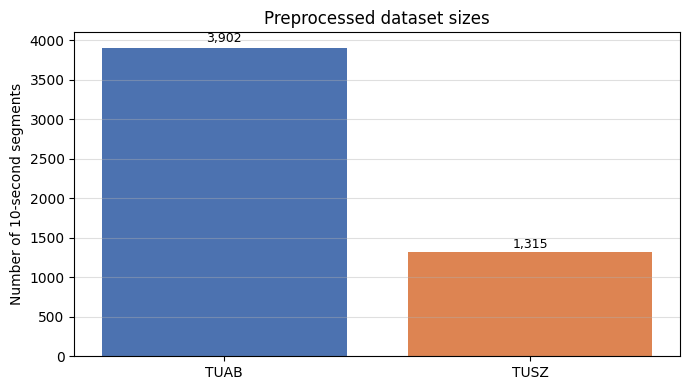

In [17]:
print("=" * 60)
print("处理结果汇总")
print("=" * 60)

summary = {}

for ds in ('tuab', 'tusz', 'tuev', 'tuep'):
    ds_dir = os.path.join(OUTPUT_DIR, ds)
    if not os.path.exists(ds_dir):
        continue
    h5_files = glob.glob(os.path.join(ds_dir, '**', '*.h5'), recursive=True)
    total_seg = 0
    for h5p in h5_files:
        try:
            with h5py.File(h5p, 'r') as hf:
                for grp in hf.values():
                    total_seg += int(grp.attrs.get('n_segments', 0))
        except Exception:
            pass
    summary[ds] = {'h5_files': len(h5_files), 'segments': total_seg}
    print(f"  {ds.upper():>6}: {len(h5_files):>5} h5 files  {total_seg:>10} segments")

for ds in ('tuar', 'tueg'):
    txt_files = glob.glob(os.path.join(OUTPUT_DIR, ds, '*.txt'))
    total_edfs = 0
    for tp in txt_files:
        with open(tp) as f:
            total_edfs += sum(1 for _ in f)
    if total_edfs:
        summary[ds] = {'edf_files': total_edfs}
        print(f"  {ds.upper():>6}: {total_edfs:>5} EDF files listed")

# 保存 summary.json
summary_path = os.path.join(OUTPUT_DIR, 'summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\nSummary saved → {summary_path}")

# 柱状图
ds_with_segs = {k: v['segments'] for k, v in summary.items() if 'segments' in v}
if ds_with_segs:
    fig, ax = plt.subplots(figsize=(7, 4))
    names = [k.upper() for k in ds_with_segs]
    vals  = list(ds_with_segs.values())
    bars  = ax.bar(names, vals, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:,}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Number of 10-second segments')
    ax.set_title('Preprocessed dataset sizes')
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

## Cell 13：验证 h5 文件格式

In [18]:
print("验证 h5 文件格式...")

for ds in ('tuab', 'tusz', 'tuev', 'tuep'):
    ds_dir = os.path.join(OUTPUT_DIR, ds)
    if not os.path.exists(ds_dir):
        continue
    h5_files = glob.glob(os.path.join(ds_dir, '**', '*.h5'), recursive=True)
    if not h5_files:
        continue

    h5p = h5_files[0]
    print(f"\n  {ds.upper()} — {Path(h5p).name}")
    try:
        with h5py.File(h5p, 'r') as hf:
            for rec_id, grp in hf.items():
                eeg_ds  = grp['eeg']
                ch_names = list(eeg_ds.attrs.get('chOrder', []))
                label    = eeg_ds.attrs.get('label', '?')
                n_segs   = grp.attrs.get('n_segments', '?')
                print(f"    rec_id:    {rec_id}")
                print(f"    eeg shape: {eeg_ds.shape}  (N_segments, 23, T)")
                print(f"    label:     {label}")
                print(f"    n_segments:{n_segs}")
                print(f"    ch_names:  {ch_names[:5]}...")

                # 取第一个segment检验数值范围
                seg = eeg_ds[0]   # (23, T)
                print(f"    value range: [{seg.min():.4f}, {seg.max():.4f}]")
                break
    except Exception as e:
        print(f"    [ERROR] {e}")

print("\n验证完成！")

验证 h5 文件格式...

  TUAB — aaaaaddm_s006_t000.h5
    rec_id:    aaaaaddm_s006_t000
    eeg shape: (125, 23, 2000)  (N_segments, 23, T)
    label:     1
    n_segments:125
    ch_names:  ['FP1', 'FP2', 'F3', 'F4', 'C3']...
    value range: [-35.2446, 51.7916]

  TUSZ — aaaaaaaq_s007_t000.h5
    rec_id:    aaaaaaaq_s007_t000
    eeg shape: (180, 23, 2000)  (N_segments, 23, T)
    label:     ?
    n_segments:180
    ch_names:  ['FP1', 'FP2', 'F3', 'F4', 'C3']...
    value range: [-0.5113, 0.2495]

验证完成！
